<a href="https://colab.research.google.com/github/Ramankur07/AIML-LAB/blob/main/code1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Graph Adjacency List:
  A: ['B', 'C']
  B: ['D', 'E']
  C: ['F']
  D: []
  E: []
  F: []


BFS Traversal Order: A -> B -> C -> D -> E -> F
DFS Traversal Order: A -> B -> D -> E -> C -> F




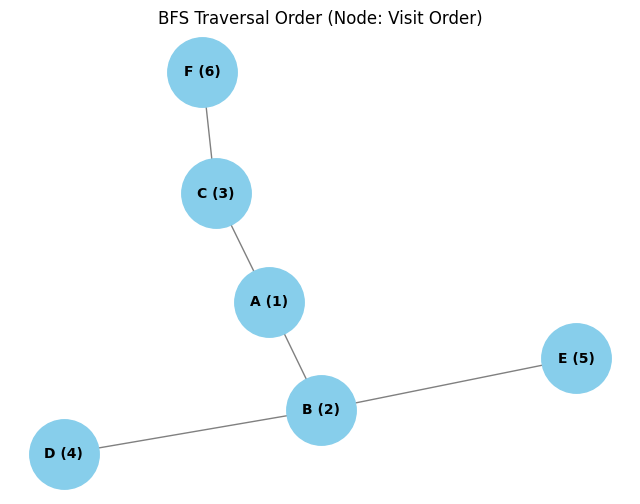

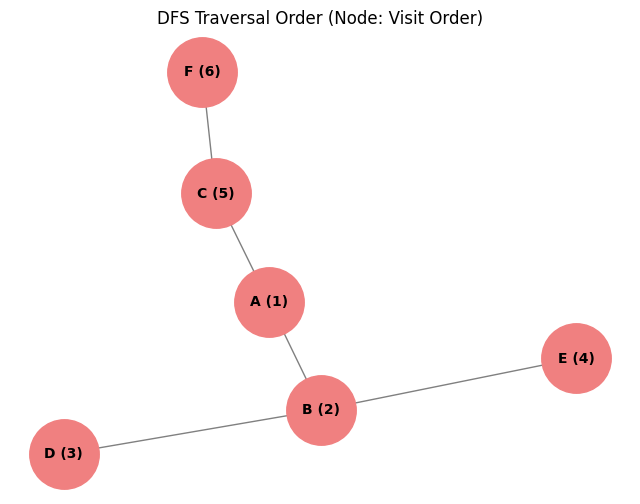

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# 1. Store the graph using an adjacency list
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

print("Graph Adjacency List:")
for node, neighbors in graph.items():
    print(f"  {node}: {neighbors}")
print("\n")

# 2. Perform a BFS traversal starting from node A.
def bfs(graph, start_node):
    visited = []
    queue = deque([start_node])
    visit_order = []
    node_visit_map = {}
    order_counter = 1

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            visit_order.append(node)
            node_visit_map[node] = order_counter
            order_counter += 1
            for neighbor in graph.get(node, []):
                if neighbor not in visited:
                    queue.append(neighbor)
    return visit_order, node_visit_map

# 3. Performs a DFS traversal starting from node A.
def dfs(graph, start_node):
    visited = []
    stack = [start_node]
    visit_order = []
    node_visit_map = {}
    order_counter = 1

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.append(node)
            visit_order.append(node)
            node_visit_map[node] = order_counter
            order_counter += 1
            # Push neighbors in reverse order to ensure a consistent
            # exploration order (e.g., alphabetical or insertion order).
            for neighbor in reversed(graph.get(node, [])):
                if neighbor not in visited:
                    stack.append(neighbor)
    return visit_order, node_visit_map

# 4. Prints both traversal orders, and draws two separate tree diagrams.

# Perform BFS
bfs_order, bfs_node_visit_map = bfs(graph, 'A')
print(f"BFS Traversal Order: {' -> '.join(bfs_order)}")

# Perform DFS
dfs_order, dfs_node_visit_map = dfs(graph, 'A')
print(f"DFS Traversal Order: {' -> '.join(dfs_order)}")
print("\n")

# Function to draw graph with visit order
def draw_graph_with_order(graph_dict, visit_map, title, node_color='skyblue'):
    G = nx.DiGraph() # Directed graph for tree-like structure

    # Add nodes and edges
    for node, neighbors in graph_dict.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    # Use a fixed seed for layout for reproducibility
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(8, 6))
    plt.title(title)

    # Create labels for nodes with visit order
    node_labels = {node: f"{node} ({visit_map.get(node, '-')})" for node in G.nodes()}

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=2500)

    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)

    # Draw node labels
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight='bold')

    plt.axis('off')
    plt.show()

# Draw BFS traversal diagram
draw_graph_with_order(graph, bfs_node_visit_map, "BFS Traversal Order (Node: Visit Order)")

# Draw DFS traversal diagram
draw_graph_with_order(graph, dfs_node_visit_map, "DFS Traversal Order (Node: Visit Order)", node_color='lightcoral')